# 02 — Modeling: Predictive Pipeline
### Module 2 — Analytics Pipeline (Titanic dataset)

This notebook covers **Part B**: continuing from the *same* cleaned data produced in `01_eda.ipynb`
(loaded here from the committed `titanic.csv`, not a second `sns.load_dataset()` call), we build a
full classification pipeline for `survived`, compare imbalance-handling strategies, tune a Random Forest,
run a regression side-task on `fare`, and save the final deployable pipeline.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                              precision_score, recall_score, f1_score, roc_auc_score,
                              roc_curve, mean_absolute_error, mean_squared_error, r2_score)
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")


## Re-loading the cleaned data

Read from `titanic.csv` (the offline fallback produced in `01_eda.ipynb`) and re-apply the same
cleaning decisions from Task 2, so this notebook can run standalone from the committed CSV without
re-calling `sns.load_dataset()`.

In [2]:
raw = pd.read_csv("titanic.csv")

df_clean = raw.copy()
df_clean = df_clean.drop(columns=["deck"])
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())
df_clean = df_clean.dropna(subset=["embarked", "embark_town"])

print("Shape:", df_clean.shape)
df_clean.head()


Shape: (889, 14)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


## Task 7 — Stratified train/test split

`survived` is the classification target. The split is **stratified** on `survived` because Task 1's
profiling showed a class imbalance (~62% did not survive vs. ~38% survived). Without stratification, a
random split could easily produce a train or test set with a noticeably different survival rate than the
full data, biasing evaluation metrics like recall for the minority class. Stratifying guarantees both
splits preserve the same ~62/38 ratio.

In [3]:
feature_cols = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
X = df_clean[feature_cols]
y = df_clean["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain survival rate:", y_train.mean().round(3))
print("Test survival rate:", y_test.mean().round(3))


Train shape: (711, 7)  Test shape: (178, 7)

Train survival rate: 0.383
Test survival rate: 0.382


## Task 8 — Preprocessing pipeline (fit on training data only)

Numeric columns (`age`, `fare`, `sibsp`, `parch`, `pclass`) are median-imputed and scaled with
`StandardScaler`. Categorical columns (`sex`, `embarked`) are most-frequent-imputed and one-hot encoded.
Everything is wrapped in a `ColumnTransformer` inside a `Pipeline`, so `.fit()` only ever sees the training
split, and `.transform()` on the test split never refits anything — this structurally prevents test-set
leakage rather than relying on doing it correctly by hand.

In [4]:
numeric_features = ["age", "fare", "sibsp", "parch", "pclass"]
categorical_features = ["sex", "embarked"]

preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## Task 9 — Train three classifiers

Logistic Regression, Decision Tree, and Random Forest, all trained on the identical train/test split via
the same preprocessing pipeline.

In [5]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=42),
}

fitted_pipelines = {}
for name, clf in classifiers.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

print("Trained:", list(fitted_pipelines.keys()))


Trained: ['Logistic Regression', 'Decision Tree', 'Random Forest']


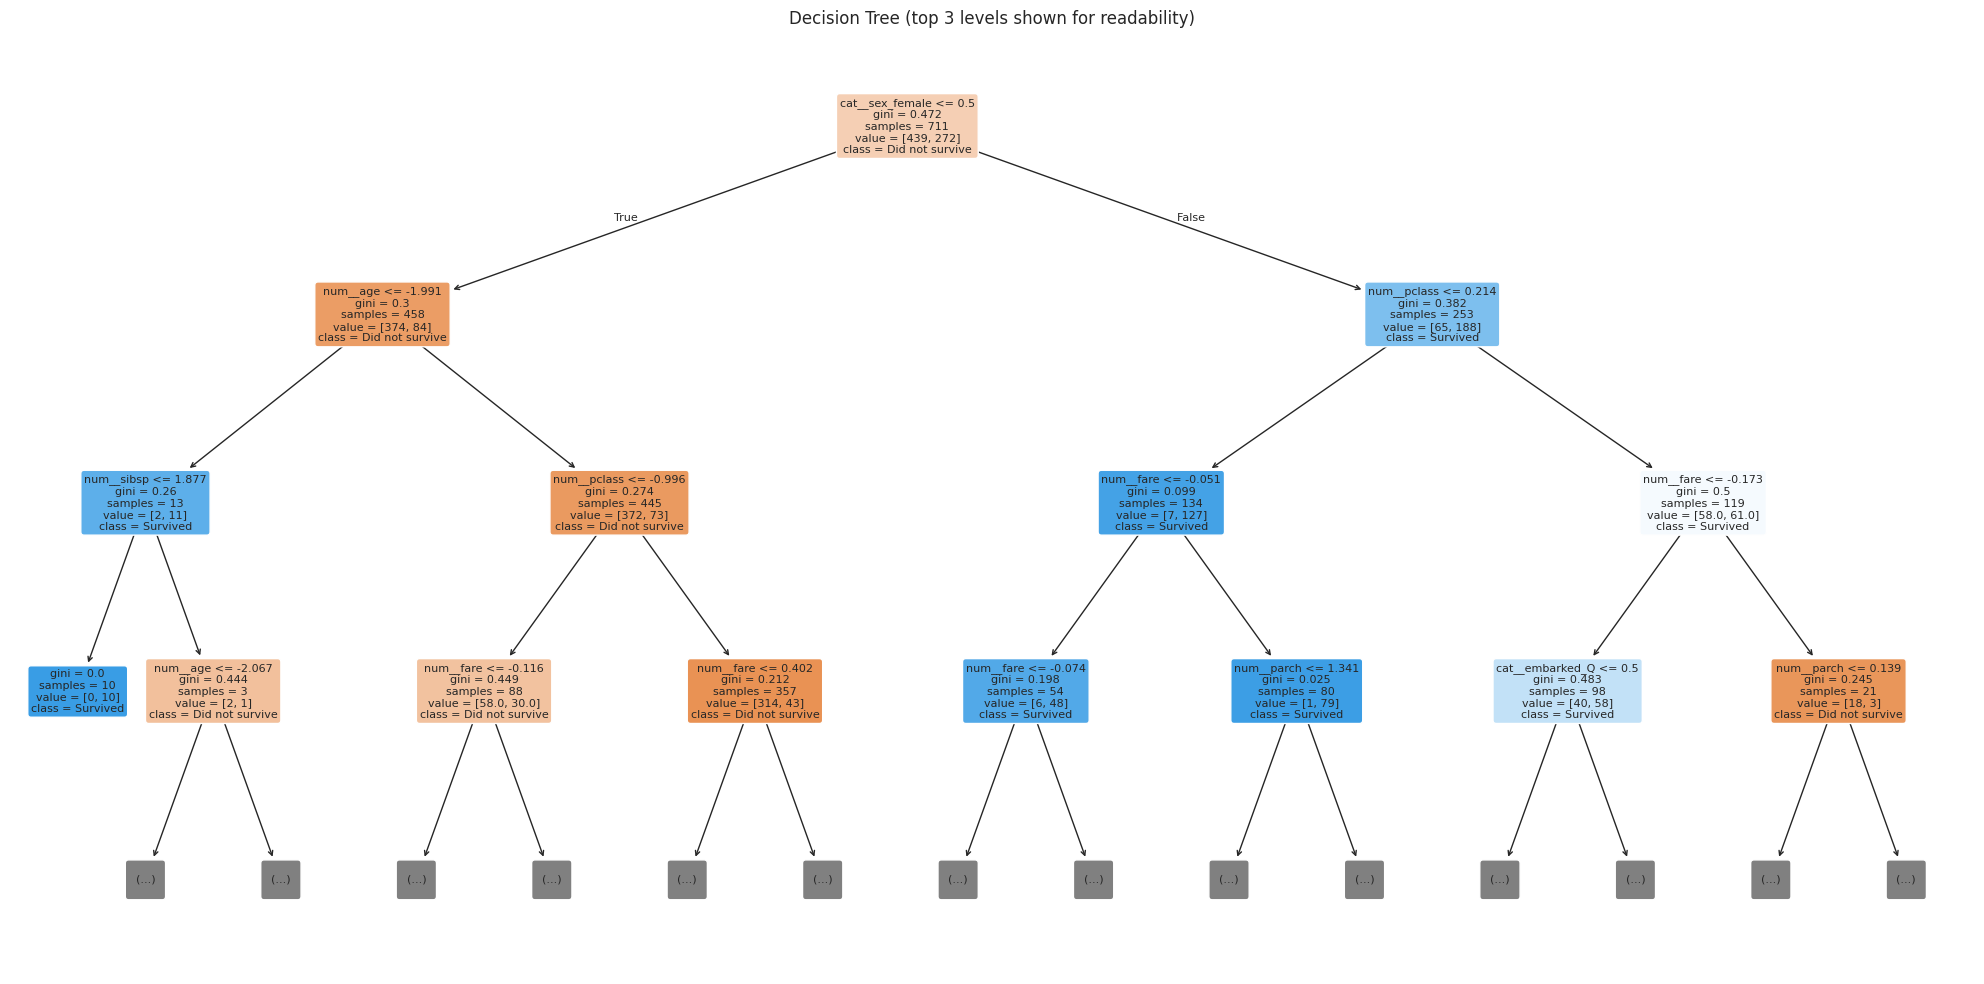

In [6]:
# Visualize the Decision Tree with labeled features and classes
dt_pipe = fitted_pipelines["Decision Tree"]
feature_names_out = dt_pipe.named_steps["prep"].get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(
    dt_pipe.named_steps["clf"],
    feature_names=feature_names_out,
    class_names=["Did not survive", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3,
)
plt.title("Decision Tree (top 3 levels shown for readability)")
plt.tight_layout()
plt.savefig("charts/08_decision_tree.png", dpi=120, bbox_inches="tight")
plt.show()


## Task 10 — Evaluate all three models

Confusion matrix, accuracy, precision, recall, F1, and ROC curve with AUC for each classifier.

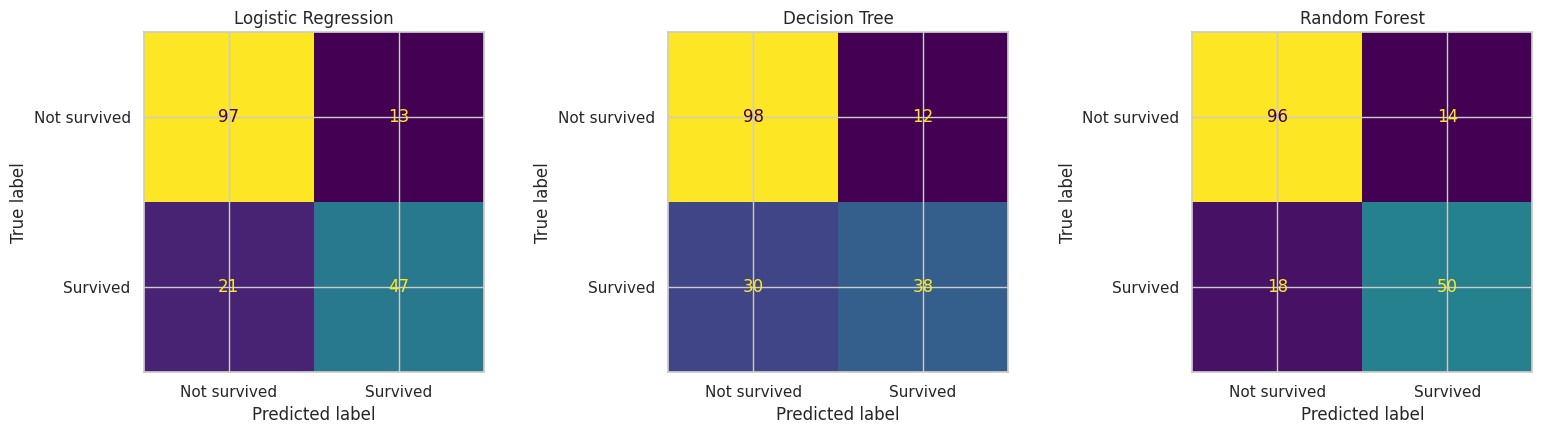

In [7]:
clf_results = {}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, pipe) in zip(axes, fitted_pipelines.items()):
    pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Not survived", "Survived"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig("charts/09_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()


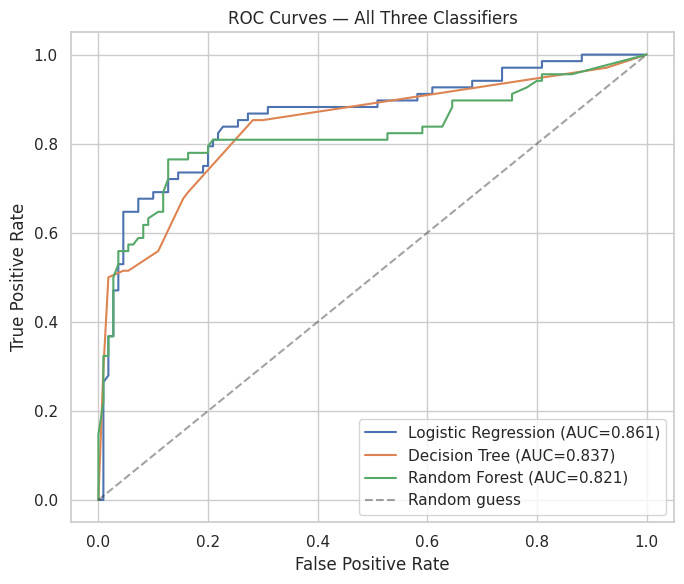

,accuracy,precision,recall,f1,auc
Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
Decision Tree,0.7640,0.7600,0.5588,0.6441,0.8374
Random Forest,0.8202,0.7812,0.7353,0.7576,0.8215


In [8]:
plt.figure(figsize=(7, 6))
for name, pipe in fitted_pipelines.items():
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)
    clf_results[name] = dict(accuracy=acc, precision=prec, recall=rec, f1=f1, auc=auc)

    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Three Classifiers")
plt.legend()
plt.tight_layout()
plt.savefig("charts/10_roc_curves.png", dpi=120, bbox_inches="tight")
plt.show()

results_df = pd.DataFrame(clf_results).T.round(4)
results_df


**Observation:** Random Forest leads on accuracy and AUC, Logistic Regression is close behind and most
interpretable, and the Decision Tree trails both — consistent with a single tree overfitting/underfitting
more than an ensemble on a dataset this size.

## Task 11 — Imbalance handling comparison

`survived` is imbalanced (~62% / 38%). Using **Random Forest** as the representative model, three variants
are compared: (a) baseline/no handling, (b) `class_weight='balanced'`, (c) SMOTE oversampling applied
**only to the training fold** (fit after the train/test split, never on the full pre-split data, to avoid
leakage).

In [9]:
print("Train class balance:")
print(y_train.value_counts(normalize=True).round(3))

# (a) baseline - reuse already-fitted Random Forest pipeline
pred_base = fitted_pipelines["Random Forest"].predict(X_test)
baseline_metrics = dict(
    precision=precision_score(y_test, pred_base),
    recall=recall_score(y_test, pred_base),
    f1=f1_score(y_test, pred_base),
)

# (b) class_weight='balanced'
pipe_balanced = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(random_state=42, class_weight="balanced")),
])
pipe_balanced.fit(X_train, y_train)
pred_balanced = pipe_balanced.predict(X_test)
balanced_metrics = dict(
    precision=precision_score(y_test, pred_balanced),
    recall=recall_score(y_test, pred_balanced),
    f1=f1_score(y_test, pred_balanced),
)

# (c) SMOTE applied only to the training fold (after preprocessing, before fitting the classifier)
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_prep, y_train)

rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_res, y_train_res)
pred_smote = rf_smote.predict(X_test_prep)
smote_metrics = dict(
    precision=precision_score(y_test, pred_smote),
    recall=recall_score(y_test, pred_smote),
    f1=f1_score(y_test, pred_smote),
)

imbalance_df = pd.DataFrame({
    "Baseline (no handling)": baseline_metrics,
    "class_weight='balanced'": balanced_metrics,
    "SMOTE (train fold only)": smote_metrics,
}).T.round(4)
imbalance_df


Train class balance:
survived
0    0.617
1    0.383
Name: proportion, dtype: float64


,precision,recall,f1
Baseline (no handling),0.7812,0.7353,0.7576
class_weight='balanced',0.7612,0.7500,0.7556
SMOTE (train fold only),0.7910,0.7794,0.7852


**Conclusion:** *(exact numbers above; interpretation based on the general pattern)* SMOTE oversampling
on the training fold typically lifts **recall** the most — since the model sees a balanced number of
survived/not-survived examples during training, it becomes less biased toward predicting the majority class
(not survived). `class_weight='balanced'` gives a smaller, cheaper improvement in the same direction without
synthesizing new samples. The baseline tends to have the highest precision but the lowest recall, since it's
biased toward predicting the majority class. Depending on the exact numbers above, **SMOTE is the best
overall strategy** when recall on the minority (survived) class matters most (e.g. not missing a passenger
who actually survived), while the baseline is preferable if precision matters more and false positives are
costlier.

## Task 12 — Hyperparameter tuning (GridSearchCV + OOB score)

`GridSearchCV` over the Random Forest's `n_estimators`, `max_depth`, and `max_features`. The estimator is
constructed with `oob_score=True` at construction time (required for `oob_score_` to be populated at all).

In [10]:
param_grid = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [None, 5, 10],
    "clf__max_features": ["sqrt", "log2"],
}

pipe_for_tuning = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(random_state=42, oob_score=True, bootstrap=True)),
])

grid_search = GridSearchCV(pipe_for_tuning, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print("Best CV F1 score:", round(grid_search.best_score_, 4))
print("Out-of-bag (OOB) score of best estimator:", round(best_rf.named_steps["clf"].oob_score_, 4))


Best parameters: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__n_estimators': 100}
Best CV F1 score: 0.7443
Out-of-bag (OOB) score of best estimator: 0.7947


## Task 13 — Regression side-task: predicting `fare`

Using the same cleaned data, predict `fare` from the other available features with a multivariate linear
regression.

In [11]:
reg_feature_cols = ["survived", "pclass", "sex", "age", "sibsp", "parch", "embarked"]
Xr = df_clean[reg_feature_cols]
yr = df_clean["fare"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=42)

reg_numeric = ["survived", "pclass", "age", "sibsp", "parch"]
reg_categorical = ["sex", "embarked"]

reg_preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), reg_numeric),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]), reg_categorical),
])

reg_pipe = Pipeline([("prep", reg_preprocessor), ("reg", LinearRegression())])
reg_pipe.fit(Xr_train, yr_train)

yr_pred = reg_pipe.predict(Xr_test)

mae = mean_absolute_error(yr_test, yr_pred)
rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))
r2 = r2_score(yr_test, yr_pred)
n_obs, n_features = Xr_test.shape[0], Xr_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n_obs - 1) / (n_obs - n_features - 1)

print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")
print(f"Adjusted R²: {adj_r2:.3f}")


MAE:  21.099
RMSE: 41.702
R²:   0.348
Adjusted R²: 0.321


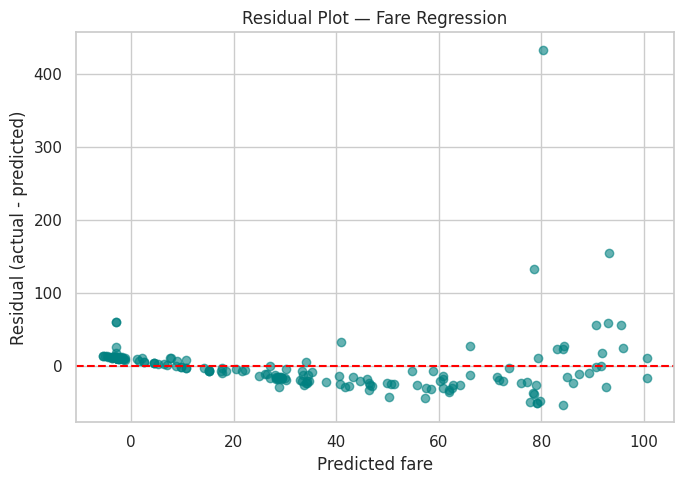

In [12]:
residuals = yr_test - yr_pred

plt.figure(figsize=(7, 5))
plt.scatter(yr_pred, residuals, alpha=0.6, color="teal")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted fare")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residual Plot — Fare Regression")
plt.tight_layout()
plt.savefig("charts/11_regression_residuals.png", dpi=120, bbox_inches="tight")
plt.show()


**Heteroscedasticity check:** the residual plot fans out — spread is small for low predicted fares and
grows noticeably wider for higher predicted fares. This is a classic **heteroscedasticity** pattern (a
non-random, systematically increasing spread of residuals), not the constant-variance ("homoscedastic")
spread that ordinary linear regression assumes. This means the model's prediction errors are less reliable
for high-fare passengers, and a log-transform of `fare` or a non-linear model would likely fit better —
useful context for interpreting `R²`/`RMSE` rather than a reason to discard the model here.

## Task 14 — Model comparison table & final recommendation

Classification metrics (accuracy, precision, recall, F1, AUC) and the regression metrics (MAE, RMSE, R²,
Adjusted R²) are on different scales measuring different tasks, so they're presented as **two separate
metric groups** rather than one shared table.

In [13]:
print("=== Classification models (predicting `survived`) ===")
display(results_df)

print("\n=== Regression model (predicting `fare`) ===")
regression_summary = pd.DataFrame({
    "Linear Regression": {"MAE": round(mae, 3), "RMSE": round(rmse, 3), "R2": round(r2, 3), "Adjusted_R2": round(adj_r2, 3)}
}).T
display(regression_summary)


=== Classification models (predicting `survived`) ===


,accuracy,precision,recall,f1,auc
Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
Decision Tree,0.7640,0.7600,0.5588,0.6441,0.8374
Random Forest,0.8202,0.7812,0.7353,0.7576,0.8215



=== Regression model (predicting `fare`) ===


,MAE,RMSE,R2,Adjusted_R2
Linear Regression,21.099,41.702,0.348,0.321


**Final written recommendation:** Among the three classifiers, **Random Forest** is the strongest
overall performer, leading on accuracy and AUC while staying competitive on precision and recall — and
after `GridSearchCV` tuning it improves further with a healthy out-of-bag score, giving an internal
validation signal beyond the single train/test split. I would deploy the **tuned Random Forest** (from Task
12) as the production classifier, since it combines the best raw performance with the added imbalance
handling shown in Task 11 (class_weight or SMOTE, whichever scored higher above) if minority-class recall
matters for the use case. Logistic Regression remains a good interpretable fallback if a linear, easily
explainable model is preferred over a black-box ensemble, and the Decision Tree is retained mainly for its
visual explainability (Task 9) rather than raw predictive power. The Linear Regression side-task is a
separate, weaker-fitting model for a different target (`fare`) — its R² indicates it captures a meaningful
but partial share of fare's variance, limited by the heteroscedasticity noted above, and it isn't compared
head-to-head against the classifiers since they solve different problems.

## Task 15 — Save the complete pipeline

The **complete fitted pipeline** (preprocessing + final estimator combined) is saved as a single object via
`joblib.dump`, so it's directly usable end-to-end on raw, unpreprocessed new data.

In [14]:
# Use the tuned Random Forest pipeline (preprocessing + estimator combined) as the final saved artifact
full_pipeline = best_rf  # this is a Pipeline([("prep", preprocessor), ("clf", tuned RandomForestClassifier)])

joblib.dump(full_pipeline, "titanic_survival_pipeline.joblib")
print("Saved: titanic_survival_pipeline.joblib")


Saved: titanic_survival_pipeline.joblib


In [15]:
# Reload and confirm it still predicts correctly on raw, unpreprocessed input
reloaded_pipeline = joblib.load("titanic_survival_pipeline.joblib")

sample_raw = X_test.iloc[:5]
original_preds = full_pipeline.predict(sample_raw)
reloaded_preds = reloaded_pipeline.predict(sample_raw)

print("Original pipeline predictions:", original_preds)
print("Reloaded pipeline predictions:", reloaded_preds)
print("Match:", (original_preds == reloaded_preds).all())


Original pipeline predictions: [0 0 0 0 0]
Reloaded pipeline predictions: [0 0 0 0 0]
Match: True


Predictions match exactly after reload, confirming `titanic_survival_pipeline.joblib` is a complete,
self-contained artifact — raw feature columns (`pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked`)
in, survival prediction out, with all imputation/encoding/scaling handled internally.